In [227]:
from dataclasses import dataclass
from typing_extensions import Self
from typing import Callable
import numpy as np
from tqdm import tqdm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from skimage.metrics import structural_similarity as ssim
from torchvision import transforms
from torch.utils.data import DataLoader
from torch import nn
import matplotlib.pyplot as plt
import torch.optim as optim
import torch.nn.functional as F
from torch.nn.utils.rnn import pad_sequence
from tqdm import tqdm
import torch

# %matplotlib widget

from typing import Optional
import matplotlib.pyplot as plt
import torch

from pileup_ml.detectors.pixels import PixelDetector, PixelModule
from pileup_ml.pixels.hits import PixelDigiEvent
from pileup_ml.pixels.patches import (
    PixelModulePatches, PixelEventPatches, _PixelEventGrid,
    event_hits_to_patches, module_patches_to_hits, event_patches_to_hits)

from pileup_ml.compression.base import CompressedPixelEvent
from numpy import cov, trace, iscomplexobj
from scipy.linalg import sqrtm

# TODO:
# Use two matrices for VQ-VAE model lossy data compression
# Divide data into 4 x 4 batches
# Find embeddings using ADCS 4 x 4 batches
# scale patches into smaller scales


In [228]:
EVENT_COUNT = 12
BATCH_SIZE = 4
PATCH_SIZE = 4

In [229]:
# Utillities
def show_image(events: np.array):
    image_plot = events.to_images()[0][1]
    plt.imshow(image_plot, cmap='gist_yarg', origin='lower')
    plt.show()
    
def plot_patch(patch: np.array):
    plt.imshow(patch, cmap='gist_yarg', origin='lower')
    plt.show()
    
def _get_ssim_value(image1: np.array, image2: np.array) -> float:
    image2_min_value = image2.min()
    image2_max_value = image2.max()
    
    ssmi_value = ssim(
        image1, 
        image2, 
        data_range=image2_max_value - image2_min_value
    )
    
    return ssmi_value

def _tensor_to_numpy(values: torch.Tensor) -> np.array:
    return values.cpu().detach().numpy()

def plot_metric_results(
    ssim_values: list[float], 
    epochs: int, 
    y_title: str, 
    title: str
) -> None:
    print("ssmi values over epochs")
    plt.style.use('fivethirtyeight')
    plt.figure(figsize=(8, 5))
    plt.plot(epochs, ssim_values)
    plt.xlabel('Epochs')
    plt.ylabel(y_title)
    plt.legend()
    plt.title(title)
    plt.show()
    
def collate_fn(batch: torch.tensor):
    tensors = [torch.tensor(x) for x in batch]    
    tensors_padded = pad_sequence(tensors, batch_first=True)
    return tensors_padded

def _get_vq_loss(recon_x, x, vq_loss):
    recon_loss = F.mse_loss(recon_x, x)
    return recon_loss + vq_loss

In [230]:
# Moduliai ir ju savybes aprasomos pixel_modules json'uose
pixel_modules = PixelModule.read_json('/data/cern/pileup_ml/detid_info/detids_bpix.json', '/data/cern/pileup_ml/detid_info/detids_fpix.json')
pix_det = PixelDetector(pixel_modules)

events_train_all = PixelDigiEvent.read_root('/data/cern/pileup_ml/premixlib2024/0001.root', pix_det)
events_train = events_train_all[:EVENT_COUNT]

events_test_all = PixelDigiEvent.read_root('/data/cern/pileup_ml/premixlib2024/0002.root', pix_det)
events_test = events_test_all[:EVENT_COUNT]

100%|██████████| 1000/1000 [00:04<00:00, 226.48it/s]


In [231]:
# Params
# batch_size = 64
learning_rate = 1e-2
# num_epochs = 80
num_epochs = 80
channels = 1
latent_dim = 64
num_embeddings = 128  # Number of vectors in the codebook
beta = 0.25 # Beta, the commitment loss weight for moving vectors closer to the cendroid
num_residual_hiddens = 3
num_residual_layers = 2


decay = 0.75
vq_epsilon = 1e-5

In [232]:
# Selecting GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Applying seed for reproducability
seed_value = 123

if device.type == "cuda":
    torch.cuda.manual_seed_all(seed_value)
else:
    torch.cuda.manual_seed(seed_value)

device

device(type='cuda')

In [233]:
events_train_display = iter(events_train)

In [234]:
# Patches prepearation
X_patches_adcs = []
X_patches = []

for event in events_train:
    event_hits_adcs = event_hits_to_patches(
        event, 
        patch_size=PATCH_SIZE
    ).as_array()
    X_patches_adcs.append(
        torch.tensor(event_hits_adcs).unsqueeze(1)
    )

# Forming without numpy arrays
for event in events_train:
    event_hits = event_hits_to_patches(
        event, 
        patch_size=PATCH_SIZE
    )
    X_patches.append(event_hits)

X_patches = iter(X_patches)

In [235]:
X_patches_adcs[0].shape

torch.Size([20742, 1, 16])

In [236]:
len(X_patches_adcs)

12

In [237]:
event_hits_sizes = [len(x_patches) for x_patches in X_patches_adcs]
min_value = min(event_hits_sizes)
max_value = max(event_hits_sizes)

print("Patch sizes:")
print(f"Min_value={min_value}")
print(f"Max_value={max_value}")

Patch sizes:
Min_value=16485
Max_value=33116


In [238]:
len(X_patches_adcs)

12

In [239]:
event_total = sum(event_hits_sizes)
event_total

286617

In [240]:
X_patches_adcs[0].shape

torch.Size([20742, 1, 16])

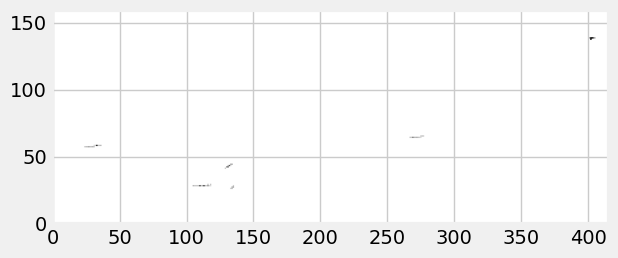

In [241]:
# plt.figure(figsize=(12, 6))
show_image(events_test[0])

In [242]:
# X_patches_batches = torch.tensor(X_patches_batches).unsqueeze(1).float()
transform = transforms.Compose([
    transforms.ToTensor(),
])
train_loader = DataLoader(
    dataset=X_patches_adcs, 
    batch_size=1, 
    shuffle=True, 
    collate_fn=collate_fn
)

In [243]:
data_sample = next(iter(train_loader))
data_sample.shape

/tmp/ipykernel_43488/3217166227.py:43: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  tensors = [torch.tensor(x) for x in batch]


torch.Size([1, 29905, 1, 16])

In [244]:
len(train_loader)

12

In [245]:
class VQEmbedding(nn.Module):
    def __init__(self, num_embeddings, embedding_dim, commitment_cost, decay, epsilon):
        super().__init__()

        self._num_embeddings = num_embeddings
        self._embedding_dim = embedding_dim

        self._embedding = nn.Embedding(self._num_embeddings, self._embedding_dim)
        self._embedding.weight.data.normal_()
        self._commitment_cost = commitment_cost

        self.register_buffer('_ema_cluster_size', torch.zeros(num_embeddings))
        self.register_buffer("_ema_w", self._embedding.weight.data.clone())
        
        self._decay = decay
        self._device = device
        self._epsilon = epsilon

    def forward(self, inputs):
        """
        Connects the module to some inputs.

        Args:
            inputs: Tensor, final dimension must be equal to embedding_dim. All other
                leading dimensions will be flattened and treated as a large batch.
        
        Returns:
            loss: Tensor containing the loss to optimize.
            quantize: Tensor containing the quantized version of the input.
            perplexity: Tensor containing the perplexity of the encodings.
            encodings: Tensor containing the discrete encodings, ie which element
                of the quantized space each input element was mapped to.
            distances
        """

        # Convert inputs from BCHW -> BHWC
        inputs = inputs.permute(0, 2, 3, 1).contiguous()
        input_shape = inputs.shape
        
        # Flatten input
        flat_input = inputs.view(-1, self._embedding_dim)
        
        # Compute distances between encoded audio frames and embedding vectors
        distances = (torch.sum(flat_input**2, dim=1, keepdim=True) 
                    + torch.sum(self._embedding.weight**2, dim=1)
                    - 2 * torch.matmul(flat_input, self._embedding.weight.t()))

        """
        encoding_indices: Tensor containing the discrete encoding indices, ie
        which element of the quantized space each input element was mapped to.
        """
        encoding_indices = torch.argmin(distances, dim=1).unsqueeze(1)
        encodings = torch.zeros(encoding_indices.shape[0], self._num_embeddings, dtype=torch.float).to(self._device)
        encodings.scatter_(1, encoding_indices, 1)


        # Sample nearest embedding
        # Use EMA to update the embedding vectors
        if self.training:
            with torch.no_grad():
                # EMA cluster size
                self._ema_cluster_size.mul_(self._decay).add_(
                    encodings.sum(0), alpha=1 - self._decay
                )

                # EMA embedding weights
                dw = torch.matmul(encodings.t(), flat_input)  # [K, C]
                self._ema_w.mul_(self._decay).add_(dw, alpha=1 - self._decay)

                # Laplace smoothing
                n = self._ema_cluster_size.sum()
                smoothed_cluster_size = (
                    (self._ema_cluster_size + self._epsilon)
                    / (n + self._num_embeddings * self._epsilon)
                    * n
                )

                self._embedding.weight.data.copy_(
                    self._ema_w / smoothed_cluster_size.unsqueeze(1)
                )

        
        avg_probs = torch.mean(encodings, dim=0)
        # Quantize and unflatten
        quantized = torch.matmul(encodings, self._embedding.weight).view(input_shape)
        # TODO: Check if the more readable self._embedding.weight.index_select(dim=1, index=encoding_indices) works better
        # Loss
        e_latent_loss = torch.mean((quantized.detach() - inputs)**2)
        commitment_loss = self._commitment_cost * e_latent_loss        
        quantized = inputs + (quantized - inputs).detach()
        perplexity = torch.exp(-torch.sum(avg_probs * torch.log(avg_probs + 1e-10)))
        """
        The perplexity a useful value to track during training.
        It indicates how many codes are 'active' on average.
        """

        quantized = quantized.view(input_shape)  # [B, H, W, C]
        quantized = quantized.permute(0, 3, 1, 2).contiguous()  # [B, C, H, W]
        # Convert quantized from BHWC -> BCHW
        return (
            quantized, 
            commitment_loss, 
            perplexity,
            encodings
        )

In [246]:
class Residual(nn.Module):
    """
    Residual Convolutional Layer
    """

    def __init__(self, in_channels, num_hiddens, num_residual_hiddens):
        """
        initialize residual CNN layer

        :param in_channels number: Number of input channels
        :param num_hiddens number: Number of hidden channels
        :param num_residual_hiddens number: Number of residual hiddens
        """
        super(Residual, self).__init__()
        self._block = nn.Sequential(
            nn.ReLU(True),
            # C: 3 -> residual hidden
            nn.Conv2d(
                in_channels=in_channels,
                out_channels=num_residual_hiddens,
                kernel_size=3,
                stride=1,
                padding=1,
                bias=False,
            ),
            nn.ReLU(True),
            # C: resiual hidden -> out_hidden
            nn.Conv2d(
                in_channels=num_residual_hiddens,
                out_channels=in_channels,
                kernel_size=1,
                stride=1,
                bias=False,
            ),
        )

    def forward(self, x):
        """
        Residual layer

        :param x numpy.ndarray: Input image
        """
        return x + self._block(x)  # residual output


class ResidualStack(nn.Module):
    """
    Residual Convolution Stack
    """

    def __init__(
        self, in_channels, num_hiddens, num_residual_layers, num_residual_hiddens
    ):
        """
        initialize residual stack

        :param in_channels number: Number of input channels
        :param num_hiddens number: Number of hidden channels
        :param num_residual_layers number: Number of residual layers in stack
        :param num_residual_hiddens number: Number of hidden residual channels
        """
        super(ResidualStack, self).__init__()
        self._num_residual_layers = num_residual_layers
        self._layers = nn.ModuleList(
            [
                Residual(in_channels, num_hiddens, num_residual_hiddens)
                for _ in range(self._num_residual_layers)
            ]
        )

    def forward(self, x):
        """
        Apply residual stack

        :param x numpy.ndarray: Input image
        """
        # Apply all residual layers in stack
        for i in range(self._num_residual_layers):
            x = self._layers[i](x)
        return F.relu(x)

In [247]:
class VQVAE(nn.Module):
    def __init__(self, debug: bool=False):
        super(VQVAE, self).__init__()
        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(channels, 16, kernel_size=2, stride=1, padding=1),
            nn.LeakyReLU(0.1),
            nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1),
            nn.LeakyReLU(0.1),
            nn.Conv2d(32, 64, kernel_size=2, stride=1, padding=1),
          
            nn.LeakyReLU(0.1),
            nn.Conv2d(64, latent_dim, kernel_size=2),
            ResidualStack(
                in_channels=latent_dim,
                num_hiddens=latent_dim,
                num_residual_layers=num_residual_layers,
                num_residual_hiddens=num_residual_hiddens,
            )
        )
        self.debug = debug

        # Vector Quantization
        self.vq_layer = VQEmbedding(
            num_embeddings, 
            latent_dim, 
            beta, 
            decay=decay, 
            epsilon=vq_epsilon
        )

        # Decoder
        self.decoder = nn.Sequential(
            ResidualStack(
                in_channels=latent_dim,
                num_hiddens=latent_dim,
                num_residual_layers=num_residual_layers,
                num_residual_hiddens=num_residual_hiddens,
            ),
            nn.ConvTranspose2d(latent_dim, 64, kernel_size=2),
            nn.LeakyReLU(0.1),
            nn.ConvTranspose2d(64, 32, kernel_size=2, stride=1, padding=1),
            nn.LeakyReLU(0.1),
            nn.ConvTranspose2d(32, 16, kernel_size=3, stride=1, padding=1),
            nn.LeakyReLU(0.1),
            nn.ConvTranspose2d(16, channels, kernel_size=2, stride=1, padding=1),
            nn.Tanh()  # Output values in range [-1, 1]
        )

    def forward(self, x):
        z_e = self.encoder(x)        
        z_q, vq_loss, perplexity, encodings = self.vq_layer(z_e)
        
        if self.debug:
            print(f"Compressed shape: {z_q.shape}")
            print(f"Codebooks: {encodings.unique().numel()}")
        
        
        x_recon = self.decoder(z_q)
        return x_recon, vq_loss, perplexity

In [248]:
model = VQVAE().to(device)
optimizer = optim.Adam(
    model.parameters(), 
    lr=learning_rate, 
    amsgrad=True
)

Epoch 1/80:   0%|          | 0/12 [00:00<?, ?it/s]/tmp/ipykernel_43488/3217166227.py:43: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  tensors = [torch.tensor(x) for x in batch]
Epoch 1/80: 100%|██████████| 12/12 [00:01<00:00,  7.62it/s, Loss=1.7e+3] 


Before compression


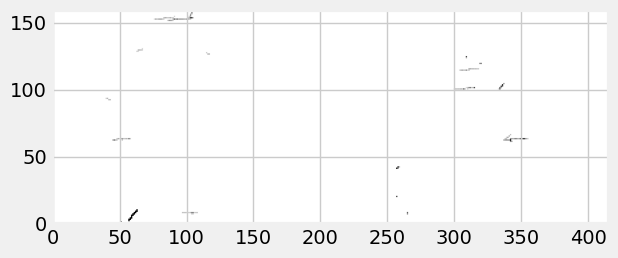

After compression


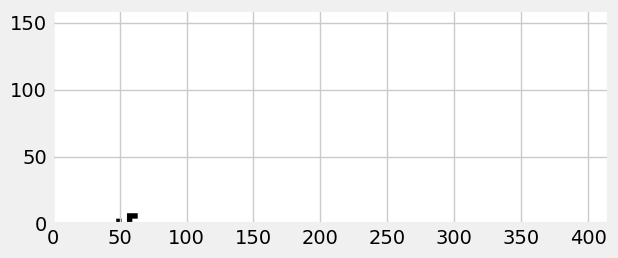

Training SSIM value: 0.9692435916691138
Perplexity: 5.919837951660156
Epoch [1/80] Average Loss: 1732.9532


Epoch 2/80: 100%|██████████| 12/12 [00:01<00:00,  7.61it/s, Loss=1.73e+3]


Epoch [2/80] Average Loss: 1724.2819


Epoch 3/80: 100%|██████████| 12/12 [00:01<00:00,  7.71it/s, Loss=1.68e+3]


Epoch [3/80] Average Loss: 1723.7181


...

Epoch [9/80] Average Loss: 1723.7013


Epoch 10/80: 100%|██████████| 12/12 [00:01<00:00,  7.67it/s, Loss=1.74e+3]


Epoch [10/80] Average Loss: 1723.7013


Epoch 11/80: 100%|██████████| 12/12 [00:01<00:00,  7.61it/s, Loss=1.73e+3]

Before compression


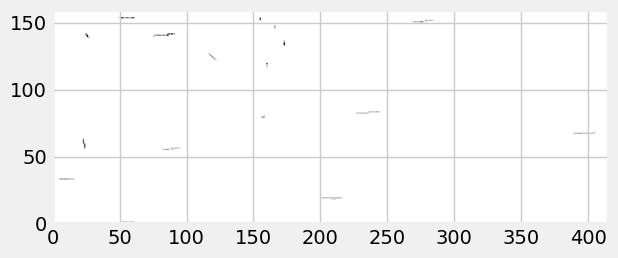

After compression


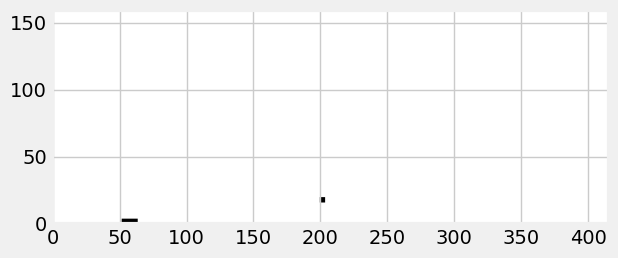

Training SSIM value: 0.968741700966869
Perplexity: 4.6392951011657715
Epoch [11/80] Average Loss: 1723.7013


Epoch 12/80: 100%|██████████| 12/12 [00:01<00:00,  7.58it/s, Loss=1.68e+3]


Epoch [12/80] Average Loss: 1723.7013


Epoch 13/80: 100%|██████████| 12/12 [00:01<00:00,  7.54it/s, Loss=1.72e+3]


Epoch [13/80] Average Loss: 1723.7013


...

Epoch [19/80] Average Loss: 1723.7013


Epoch 20/80: 100%|██████████| 12/12 [00:01<00:00,  7.66it/s, Loss=1.68e+3]


Epoch [20/80] Average Loss: 1723.7013


Epoch 21/80: 100%|██████████| 12/12 [00:01<00:00,  7.63it/s, Loss=1.77e+3]

Before compression


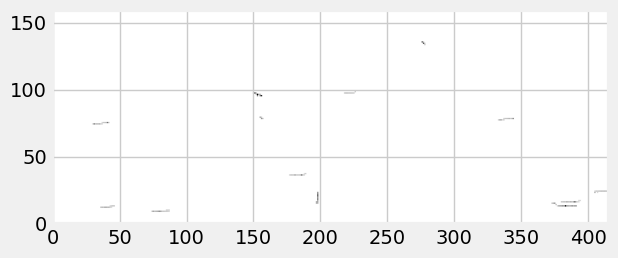

After compression


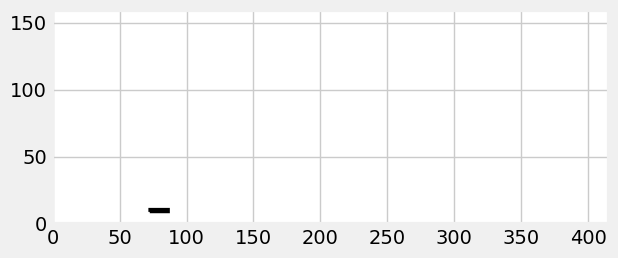

Training SSIM value: 0.9748751678172848
Perplexity: 4.542983055114746
Epoch [21/80] Average Loss: 1723.7013


Epoch 22/80: 100%|██████████| 12/12 [00:01<00:00,  7.67it/s, Loss=1.71e+3]


Epoch [22/80] Average Loss: 1723.7013


Epoch 23/80: 100%|██████████| 12/12 [00:01<00:00,  7.72it/s, Loss=1.72e+3]


Epoch [23/80] Average Loss: 1723.7013


...

Epoch [29/80] Average Loss: 1723.7013


Epoch 30/80: 100%|██████████| 12/12 [00:01<00:00,  7.70it/s, Loss=1.73e+3]


Epoch [30/80] Average Loss: 1723.7013


Epoch 31/80: 100%|██████████| 12/12 [00:01<00:00,  7.79it/s, Loss=1.73e+3]


Before compression


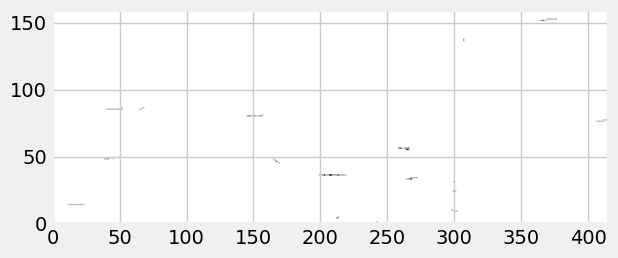

After compression


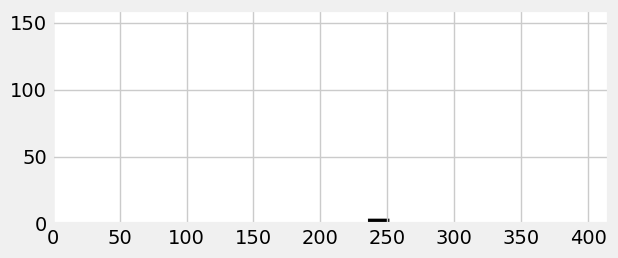

Training SSIM value: 0.9720640906379772
Perplexity: 4.512587547302246
Epoch [31/80] Average Loss: 1723.7013


Epoch 32/80: 100%|██████████| 12/12 [00:01<00:00,  7.79it/s, Loss=1.7e+3] 


Epoch [32/80] Average Loss: 1723.7013


Epoch 33/80: 100%|██████████| 12/12 [00:01<00:00,  7.69it/s, Loss=1.72e+3]


Epoch [33/80] Average Loss: 1723.7013


...

Epoch [39/80] Average Loss: 1723.7013


Epoch 40/80: 100%|██████████| 12/12 [00:01<00:00,  7.82it/s, Loss=1.68e+3]


Epoch [40/80] Average Loss: 1723.7013


Epoch 41/80: 100%|██████████| 12/12 [00:01<00:00,  7.72it/s, Loss=1.74e+3]

Before compression


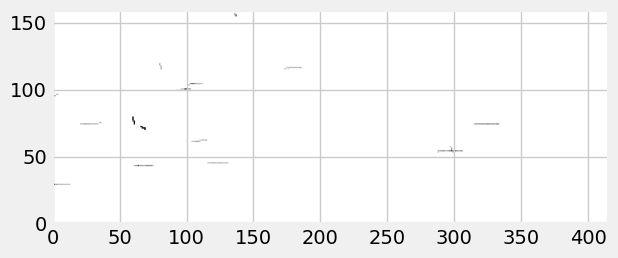

After compression


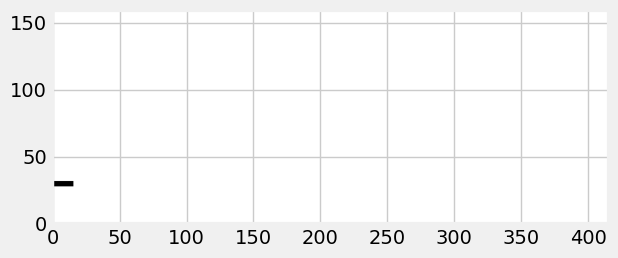

Training SSIM value: 0.970610918834128
Perplexity: 4.52606725692749
Epoch [41/80] Average Loss: 1723.7013


Epoch 42/80: 100%|██████████| 12/12 [00:01<00:00,  7.82it/s, Loss=1.72e+3]


Epoch [42/80] Average Loss: 1723.7013


Epoch 43/80: 100%|██████████| 12/12 [00:01<00:00,  7.70it/s, Loss=1.73e+3]


Epoch [43/80] Average Loss: 1723.7013


...

Epoch [49/80] Average Loss: 1723.7013


Epoch 50/80: 100%|██████████| 12/12 [00:01<00:00,  7.68it/s, Loss=1.73e+3]


Epoch [50/80] Average Loss: 1723.7013


Epoch 51/80: 100%|██████████| 12/12 [00:01<00:00,  7.77it/s, Loss=1.73e+3]

Before compression


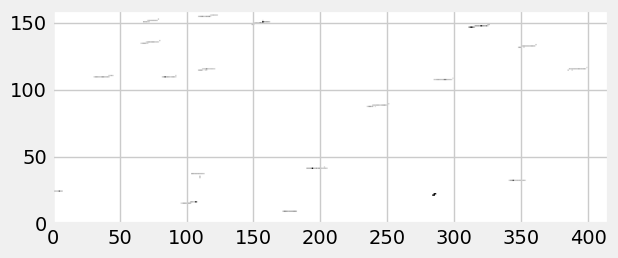

After compression


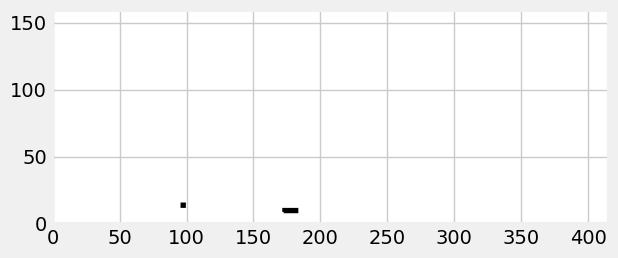

Training SSIM value: 0.9569277045428692
Perplexity: 4.711880207061768
Epoch [51/80] Average Loss: 1723.7013


Epoch 52/80: 100%|██████████| 12/12 [00:01<00:00,  7.91it/s, Loss=1.72e+3]


Epoch [52/80] Average Loss: 1723.7013


Epoch 53/80: 100%|██████████| 12/12 [00:01<00:00,  7.89it/s, Loss=1.72e+3]


Epoch [53/80] Average Loss: 1723.7013


...

Epoch [59/80] Average Loss: 1723.7013


Epoch 60/80: 100%|██████████| 12/12 [00:01<00:00,  7.63it/s, Loss=1.72e+3]


Epoch [60/80] Average Loss: 1723.7013


Epoch 61/80: 100%|██████████| 12/12 [00:01<00:00,  7.62it/s, Loss=1.73e+3]


Before compression


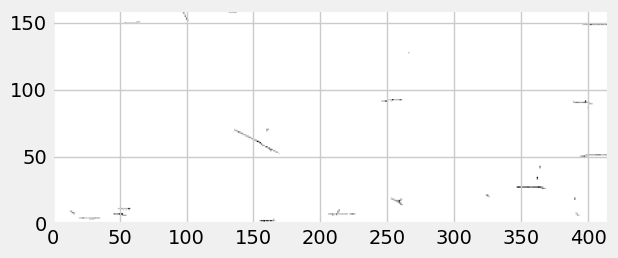

After compression


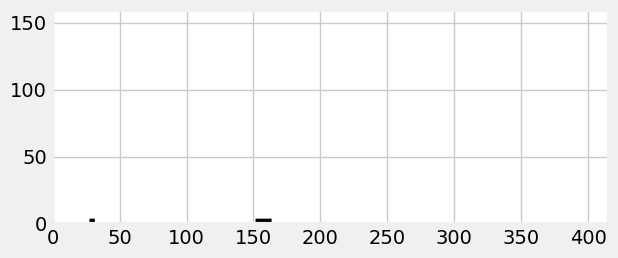

Training SSIM value: 0.9557021788817639
Perplexity: 4.7343549728393555
Epoch [61/80] Average Loss: 1723.7013


Epoch 62/80: 100%|██████████| 12/12 [00:01<00:00,  7.62it/s, Loss=1.68e+3]


Epoch [62/80] Average Loss: 1723.7013


Epoch 63/80: 100%|██████████| 12/12 [00:01<00:00,  7.53it/s, Loss=1.68e+3]


Epoch [63/80] Average Loss: 1723.7013


...

Epoch [69/80] Average Loss: 1723.7013


Epoch 70/80: 100%|██████████| 12/12 [00:01<00:00,  7.77it/s, Loss=1.73e+3]


Epoch [70/80] Average Loss: 1723.7013


Epoch 71/80: 100%|██████████| 12/12 [00:01<00:00,  7.72it/s, Loss=1.74e+3]

Before compression


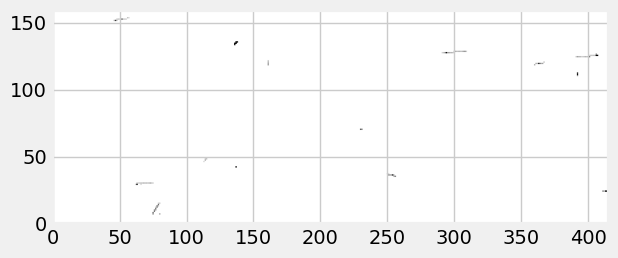

After compression


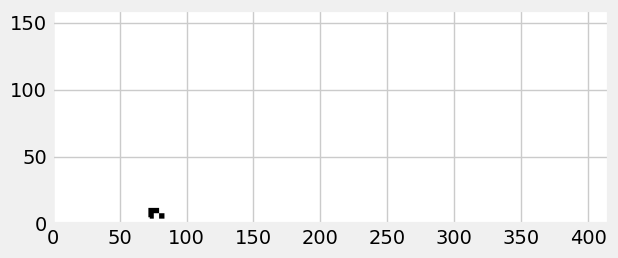

Training SSIM value: 0.9757398913743887
Perplexity: 4.689085006713867
Epoch [71/80] Average Loss: 1723.7013


Epoch 72/80: 100%|██████████| 12/12 [00:01<00:00,  7.74it/s, Loss=1.72e+3]


Epoch [72/80] Average Loss: 1723.7013


Epoch 73/80: 100%|██████████| 12/12 [00:01<00:00,  7.80it/s, Loss=1.7e+3] 


Epoch [73/80] Average Loss: 1723.7013


...

Epoch [78/80] Average Loss: 1723.7013


Epoch 79/80: 100%|██████████| 12/12 [00:01<00:00,  7.85it/s, Loss=1.74e+3]


Epoch [79/80] Average Loss: 1723.7013


Epoch 80/80: 100%|██████████| 12/12 [00:01<00:00,  7.59it/s, Loss=1.73e+3]

Epoch [80/80] Average Loss: 1723.7013


In [249]:
# loss
average_loss_values = []

# ssim
ssim_values = []

# perplexity
perplexity_values = []

epoch_values = list(range(num_epochs))

for epoch in epoch_values:
    model.train()
    train_loss = 0

    # Use tqdm for the progress bar
    progress_bar = tqdm(
        enumerate(train_loader), 
        total=len(train_loader), 
        desc=f'Epoch {epoch+1}/{num_epochs}'
    )
    for batch_idx, patches_adcs in progress_bar:
        patches_adcs = patches_adcs.float()
        patches_adcs = patches_adcs.to(device)

        optimizer.zero_grad()
        
        # Required for treating as images
        patches_adcs = patches_adcs.permute(0, 2, 1, 3)  # [B, C, N, W]

        B, C, N, W = patches_adcs.shape

        target = patches_adcs.view(B * N, C, 1, W)

        recon_batch, vq_loss, perplexity = model(
            target
        )
    
        loss = _get_vq_loss(recon_batch, target, vq_loss)
        loss.backward()
        train_loss += loss.item()
        optimizer.step()        

        # Update tqdm description with current loss
        progress_bar.set_postfix({'Loss': loss.item()})
    
    if epoch % 10 == 0:
        with torch.no_grad():            
            # selecting events before reconstruction
            used_event_hits = next(events_train_display)
            print("Before compression")
            show_image(used_event_hits)
            
            target_patches_check = event_hits_to_patches(
                used_event_hits, 
                patch_size=PATCH_SIZE
            ).as_array()
            target_patches_check = torch.tensor(target_patches_check).unsqueeze(1).unsqueeze(1)
            target_patches_check = target_patches_check.float().to(device)

            target_patches_check_tensor = target_patches_check.float().to(device)
            target_patches_check_tensor = target_patches_check.permute(0, 2, 1, 3)

            B, C, N, W = target_patches_check_tensor.shape
            target_eval = target_patches_check_tensor.view(B * N, C, 1, W)

            
            recon_patches_batch, _, perplexity = model(target_eval)
            recon_patches_batch = recon_patches_batch.view(B, N, C, W)
            reconstructed_patches_adcs = _tensor_to_numpy(recon_patches_batch)
            perplexity_values.append(perplexity.cpu().numpy())
            
            # Creating compressed patches object
            compressed_event = event_hits_to_patches(
                used_event_hits, 
                patch_size=PATCH_SIZE
            )
            event_patches_decompressed = PixelEventPatches(
                detector=pix_det,
                patch_size=PATCH_SIZE,
                event_id=compressed_event.event_id,
                det_ids=compressed_event.det_ids,
                rows=compressed_event.rows,
                cols=compressed_event.cols,
                adcs=reconstructed_patches_adcs,
                occupancy=np.arange(64)
            )
            
            # displaying reconstructed module hits based on train patches
            reconstructed_event_hits = event_patches_to_hits(
                event_patches_decompressed
            )
            
            print("After compression")
            show_image(reconstructed_event_hits)
            
            ssim_value = _get_ssim_value(
                used_event_hits.to_images()[0][1], 
                reconstructed_event_hits.to_images()[0][1]
            )
            print(f"Training SSIM value: {ssim_value}")
            
            ssim_values.append(ssim_value)
            
            print(f"Perplexity: {perplexity}")
            
        
    avg_loss = train_loss / len(train_loader)
    average_loss_values.append(avg_loss)
    
    print(f'Epoch [{epoch + 1}/{num_epochs}] Average Loss: {avg_loss:.4f}')

In [250]:
event_patches_adcs = [
    torch.tensor(
        event_hits_to_patches(event, PATCH_SIZE).as_array()
    ).float().unsqueeze(1).transpose(0, 1).unsqueeze(1)
    for event in events_test
]
X_test = iter(event_patches_adcs)
with torch.no_grad():
    patches_test = next(X_test)
    patches_part = patches_test.permute(0, 1, 2, 3) 
    B, C, N, W = patches_part.shape
    x = patches_part.view(B * N, C, 1, W)
    patches_part = x.to(device)
    model = VQVAE(debug=True).to(device)
    z = model.encoder(patches_part)
    z, vq_loss, perplexity, encodings = model.vq_layer(z)
    # z = z_q.permute(3, 2, 0, 1)

    # # flatten spatial grid
    # z = z.reshape(-1, z.shape[-1])

    # # convert to numpy
    # z = z.detach().cpu().numpy()    
    
    # intitial: torch.Size([3, 1, 95539, 16])
    # TODO: understand why width went from 16 to 19 in latent space
    print(f"Latent shape: {z.shape}")
    

Latent shape: torch.Size([10871, 64, 2, 17])


ssmi values over epochs


/tmp/ipykernel_43488/3217166227.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


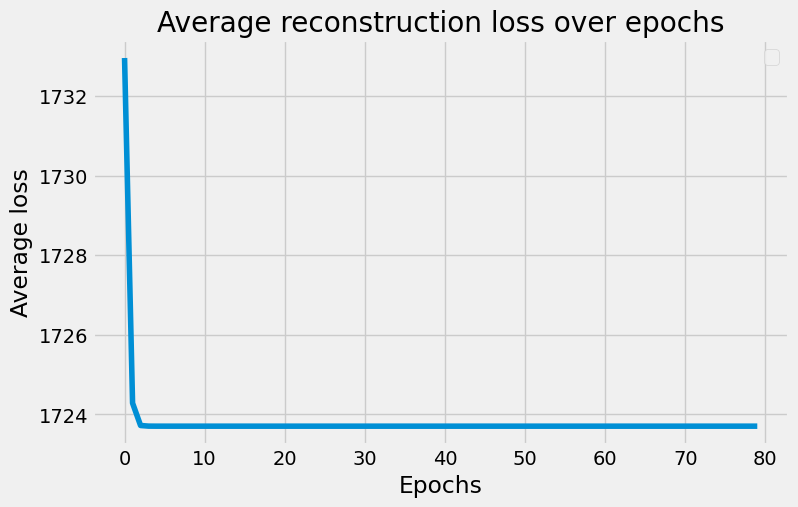

In [251]:
plot_metric_results(
    average_loss_values, 
    epoch_values, 
    "Average loss", 
    "Average reconstruction loss over epochs"
)

In [252]:
torch.save(model.state_dict(), "vq_vae_pileup.pth")

In [253]:
# Test model with unseen data
event_patches_adcs = [
    torch.tensor(
        event_hits_to_patches(event, PATCH_SIZE).as_array()
    ).float().unsqueeze(1).transpose(0, 1)
    for event in events_test
]
print(f"Events test: {len(events_test)}")
print(f"Event patches: {len(event_patches_adcs[0])}")


Events test: 12
Event patches: 1


In [254]:
# Train model with unseen data
event_test_patches = [
    event_hits_to_patches(event, PATCH_SIZE)
    for event in events_test
]
event_test_patches = iter(event_test_patches)
event_test_first = next(event_test_patches)

In [255]:
event_patches_adcs[0].shape

torch.Size([1, 10871, 16])

In [256]:
# testing with new data
event_patches = iter(event_patches_adcs)
model.load_state_dict(torch.load("vq_vae_pileup.pth"))
model = model.to(device)
model.eval()    

event_patches_decompressed = None
event_hits = None

with torch.no_grad():
    patches = next(event_patches)
    patches = patches.unsqueeze(1).to(device)
    patches = patches.permute(0, 1, 2, 3) 
    B, C, N, W = patches.shape
    x = patches.view(B * N, C, 1, W)
    patches = x.to(device)
    
    patches_batch, _, _ = model(patches)
    
    # Make the first decompressed event
    event_patches_decompressed = PixelEventPatches(
        detector=pix_det,
        patch_size=PATCH_SIZE,
        event_id=event_test_first.event_id,
        det_ids=event_test_first.det_ids,
        rows=event_test_first.rows,
        cols=event_test_first.cols,
        adcs=patches_batch.cpu().detach().numpy(),
        occupancy=np.arange(64)
    )
    event_hits = event_patches_to_hits(
        event_patches_decompressed
    )
    print(event_hits.adcs)

Compressed shape: torch.Size([10871, 64, 2, 17])
Codebooks: 2
[0.32162264 0.3179404  0.31780908 0.31812006 0.30326188 0.26852673
 0.24406053 0.2873819  0.31965607 0.33068052 0.28550568 0.25701493
 0.19602309 0.2943108  0.35716408 0.20167588 0.31957224 0.27763474
 0.35231853 0.30926502 0.268316   0.28694028 0.31943443 0.31653675
 0.3175982  0.31761822 0.31761822 0.3176097  0.31793308 0.32023123
 0.33866432 0.02206983 0.15245412 0.2893594  0.18481618 0.40283376
 0.27541828 0.25169113 0.30797985 0.3154987  0.31754917 0.31761825
 0.31761822 0.3176097  0.31793308 0.32023123 0.33866432 0.02633606
 0.2901212  0.25283635 0.39621273 0.26280597 0.25009733 0.29468685
 0.31853646 0.3163528  0.3175982  0.31761825 0.31761822 0.3176097
 0.31793308 0.32023123 0.33866432]


In [257]:
event_test = event_hits_to_patches(events_test[0], PATCH_SIZE).as_array()
print(f"Before compression: events dimensions: {event_test.shape}")

Before compression: events dimensions: (10871, 16)


In [258]:
print(f"After reconstruction: events dimensions: {patches_batch.view(-1, PATCH_SIZE**2).shape}")

After reconstruction: events dimensions: torch.Size([10871, 16])


In [259]:
# calculate frechet inception distance
def calculate_fid(act1, act2):
	# calculate mean and covariance statistics
	mu1, sigma1 = act1.mean(axis=0), cov(act1, rowvar=False)
	mu2, sigma2 = act2.mean(axis=0), cov(act2, rowvar=False)
	# calculate sum squared difference between means
	ssdiff = np.sum((mu1 - mu2)**2.0)
	# calculate sqrt of product between cov
	covmean = sqrtm(sigma1.dot(sigma2))
	# check and correct imaginary numbers from sqrt
	if iscomplexobj(covmean):
		covmean = covmean.real
	# calculate score
	fid = ssdiff + trace(sigma1 + sigma2 - 2.0 * covmean)
	return fid



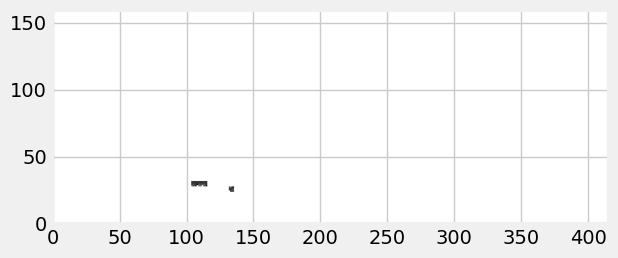

SSIM (original vs new) = 0.9877937790972414
FID: 0.06511268593280738


/tmp/ipykernel_43488/1682554401.py:9: LinAlgWarning: Matrix is singular. The result might be inaccurate or the array might not have a square root.
  covmean = sqrtm(sigma1.dot(sigma2))


In [260]:
# Plot reconstructed particle events after decompression
if event_hits:
    show_image(event_hits)
    
    # computing SSIM - Structural simalarity 
    events_test_original = events_test[0].to_images()[0][1]
    events_test_recons = event_hits.to_images()[0][1]
    
    recon_min_value = events_test_recons.min()
    recon_max_value = events_test_recons.max()
    
    ssmi_value = ssim(
        events_test_original, 
        events_test_recons, 
        data_range=recon_max_value - recon_min_value
    )
    
    print(f"SSIM (original vs new) = {ssmi_value}")
    
    fid_value = calculate_fid(events_test_original, events_test_recons)
    print(f"FID: {fid_value}")
    
    
# TODO: check SSIM metric value, latent vectors

ssmi values over epochs


/tmp/ipykernel_43488/3217166227.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


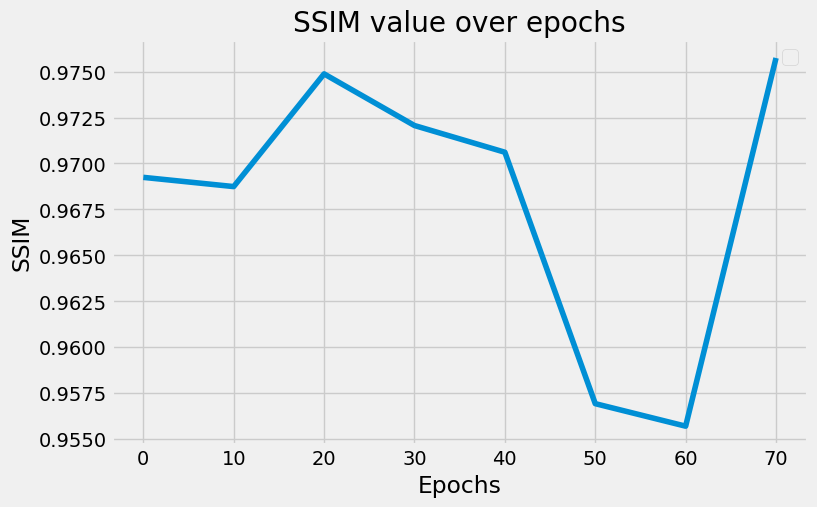

In [261]:
plot_metric_results(
    ssim_values, 
    epoch_values[::10], 
    "SSIM", 
    "SSIM value over epochs"
)

ssmi values over epochs


/tmp/ipykernel_43488/3217166227.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


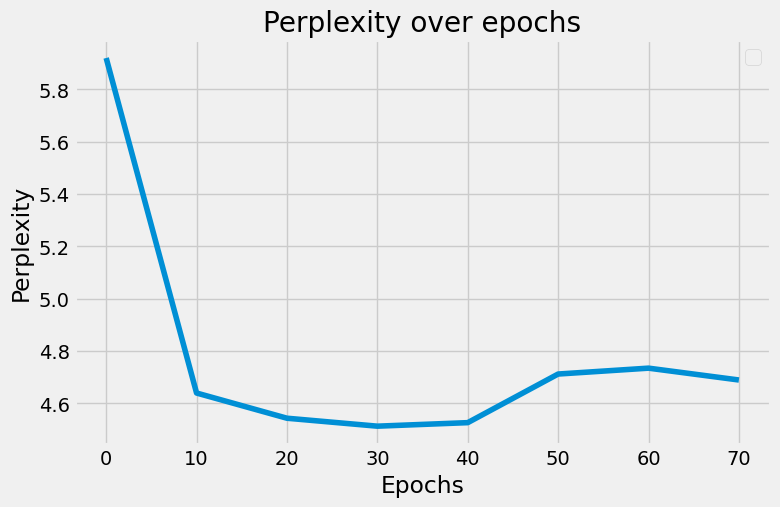

In [262]:
plot_metric_results(
    perplexity_values, 
    epoch_values[::10], 
    "Perplexity", 
    "Perplexity over epochs"
)
# Result: 1 try uses 7 codebooks at 10 epochs
# Result: 2 try uses 8 codebooks at 10 epochs with decay = 0.75